# ML Noise Generator Data Pipeline (Feature-Specific)
This notebook creates the initial ground-truth alignment for a machine-learning based noise generator.
It aligns multi-view scans with the perfect CAD model using ICP, and then extracts noise for **specific isolated features**.

In [20]:
# ==========================================
# 1. CONFIGURATION & IMPORTS
# ==========================================
import os
import math
import copy
import open3d as o3d
import numpy as np
from scipy.spatial.transform import Rotation as R
import pandas as pd
import re
import tqdm
import glob
import matplotlib.pyplot as plt

EXPERIMENT = "test_6_noise"
DATA_DIR = f"pcd_data/testing_data/{EXPERIMENT}"
SOURCE_PATH = "workpiece/workpiece31/workpiece.stl"  # CAD model
# FEATURE_PATH = "workpiece/workpiece31/surface2.stl"  # Feature to isolate
WORKPIECE_DIR = "workpiece/workpiece31"
NUMBER_OF_POINTS = 40000


# Load Initial Guesses

SIM_DIR = f"viewpoints_candidate/testing_data/{EXPERIMENT}"
PROCESSED_DIR = f"processed_data/{EXPERIMENT}"
FULL_TRANSFORM_SAVE_DIR = f'evaluation_result/{EXPERIMENT}/merge_full_transformation.npy'
merge_full_transformation = np.load(FULL_TRANSFORM_SAVE_DIR)
print(f"Successfully loaded pre-computed ICP transformation from: {FULL_TRANSFORM_SAVE_DIR}")

Successfully loaded pre-computed ICP transformation from: evaluation_result/test_6_noise/merge_full_transformation.npy


In [26]:
# ==========================================
# 7. MULTI-FEATURE MASKING & POINTWISE NOISE EXTRACTION
# ==========================================
import glob
import math
import numpy as np
import pandas as pd
import os
import open3d as o3d

extracted_noise_data = []
MAX_NOISE_THRESHOLD = 15.0  # Increased to catch high-noise points
MASK_THRESHOLD = 20.0       # Increased generous mask for real points

feature_files = glob.glob(os.path.join(WORKPIECE_DIR, "surface*.stl"))
if not feature_files:
    print(f"No surface STL files found in {WORKPIECE_DIR}!")

for feature_path in feature_files:
    feature_id = os.path.basename(feature_path).split('.')[0]
    print(f"\nProcessing {feature_id}...")
    
    mesh_feature = o3d.io.read_triangle_mesh(feature_path)
    mesh_feature.compute_vertex_normals()
    pcd_feature_full = mesh_feature.sample_points_uniformly(number_of_points=NUMBER_OF_POINTS)
    kdtree_feature = o3d.geometry.KDTreeFlann(pcd_feature_full)
    
    print("Extracting noise across all viewpoints...")
    processed_files = glob.glob(os.path.join(PROCESSED_DIR, "viewpoint_simulated_*.pcd"))
    
    for processed_path in processed_files:
        basename = os.path.basename(processed_path)
        view_idx_str = basename.replace("viewpoint_simulated_", "").replace(".pcd", "")
        view_idx = int(view_idx_str)
        
        sim_path = os.path.join(SIM_DIR, f"viewpoint_simulated_{view_idx}.pcd")
        pose_path = os.path.join(SIM_DIR, f"viewpoint_pose_{view_idx}.npy")
        
        if not os.path.exists(sim_path) or not os.path.exists(pose_path):
            continue
            
        # A) Load Real Scan
        pcd_real_down = o3d.io.read_point_cloud(processed_path)
        T_cam_to_obj = np.load(pose_path)
        T_obj_to_cam = np.linalg.inv(T_cam_to_obj)
        T_target_to_object = np.linalg.inv(merge_full_transformation)
        
        pcd_real_down.transform(T_target_to_object)
        pcd_real_down.transform(T_obj_to_cam)
        
        # B) Load Simulated Scan
        pcd_sim_down = o3d.io.read_point_cloud(sim_path)
        
        # Ensure normals exist and transform to camera space
        if not pcd_sim_down.has_normals():
            pcd_sim_down.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=10.0, max_nn=30))
            pcd_sim_down.orient_normals_towards_camera_location(camera_location=np.array([0., 0., 0.]))
            # Flip them to point OUT of the surface (away from camera)
            normals = np.asarray(pcd_sim_down.normals)
            pcd_sim_down.normals = o3d.utility.Vector3dVector(-normals)
            
        pcd_sim_down.transform(T_obj_to_cam)
        
        T_cam_to_obj_matrix = T_cam_to_obj  
        sim_points_cam = np.asarray(pcd_sim_down.points)
        sim_normals_cam = np.asarray(pcd_sim_down.normals)
        real_points_cam = np.asarray(pcd_real_down.points)
        
        # C) Mask Simulated Points (BUG FIXED: Strict masking to feature only!)
        sim_points_obj = np.dot(sim_points_cam, T_cam_to_obj_matrix[:3, :3].T) + T_cam_to_obj_matrix[:3, 3]
        valid_sim_indices = []
        for i, pt_obj in enumerate(sim_points_obj):
            [k, idx, dist_sq] = kdtree_feature.search_knn_vector_3d(pt_obj, 1)
            if k > 0 and math.sqrt(dist_sq[0]) <= 2.0:  # Fix: Ensures point is on the feature
                valid_sim_indices.append(i)
                
        if len(valid_sim_indices) < 10:
            continue
            
        sim_points_final = sim_points_cam[valid_sim_indices]
        sim_normals_final = sim_normals_cam[valid_sim_indices]
        
        # Mask Real Points
        real_points_obj = np.dot(real_points_cam, T_cam_to_obj_matrix[:3, :3].T) + T_cam_to_obj_matrix[:3, 3]
        valid_real_indices = []
        for i, pt_obj in enumerate(real_points_obj):
            [k, idx, dist_sq] = kdtree_feature.search_knn_vector_3d(pt_obj, 1)
            if k > 0 and math.sqrt(dist_sq[0]) <= MASK_THRESHOLD:
                valid_real_indices.append(i)
                
        if len(valid_real_indices) < 10:
            continue
            
        real_points_final = real_points_cam[valid_real_indices]
        
        # D) Bipartite Matching
        real_pcd_temp = o3d.geometry.PointCloud()
        real_pcd_temp.points = o3d.utility.Vector3dVector(real_points_final)
        kdtree_noise = o3d.geometry.KDTreeFlann(real_pcd_temp)
        
        edges = []
        for i in range(len(sim_points_final)):
            sim_pt = sim_points_final[i]
            [k, idx, dist_sq] = kdtree_noise.search_knn_vector_3d(sim_pt, 5) 
            for j in range(k):
                dist = math.sqrt(dist_sq[j])
                if dist <= MAX_NOISE_THRESHOLD:
                    edges.append((dist, i, idx[j])) 
                    
        edges.sort(key=lambda x: x[0])
        
        matched_sim = set()
        matched_real = set()
        
        for dist, sim_idx, real_idx in edges:
            if sim_idx not in matched_sim and real_idx not in matched_real:
                matched_sim.add(sim_idx)
                matched_real.add(real_idx)
                
                sim_pt = sim_points_final[sim_idx]
                sim_norm = sim_normals_final[sim_idx]
                real_pt = real_points_final[real_idx]
                
                # Calculate Angle of Incidence (AoI)
                camera_dir = -sim_pt
                camera_dir_norm = camera_dir / np.linalg.norm(camera_dir)
                normal_norm = sim_norm / np.linalg.norm(sim_norm)
                
                cos_theta = np.clip(np.dot(camera_dir_norm, normal_norm), -1.0, 1.0)
                aoi = np.degrees(np.arccos(cos_theta))
                if aoi > 90:
                    aoi = 180 - aoi

                extracted_noise_data.append({
                    'view_id': view_idx,
                    'feature_id': feature_id,
                    'sim_x': sim_pt[0],
                    'sim_y': sim_pt[1],
                    'sim_z': sim_pt[2],
                    'nx': sim_norm[0],
                    'ny': sim_norm[1],
                    'nz': sim_norm[2],
                    'aoi': aoi,
                    'dx': real_pt[0] - sim_pt[0],
                    'dy': real_pt[1] - sim_pt[1],
                    'dz': real_pt[2] - sim_pt[2],
                    'error_magnitude': dist,
                    'is_valid_scan': 1
                })
                
        # E) Record Dropped Points
        for sim_idx in range(len(sim_points_final)):
            if sim_idx not in matched_sim:
                sim_pt = sim_points_final[sim_idx]
                sim_norm = sim_normals_final[sim_idx]
                
                camera_dir = -sim_pt
                camera_dir_norm = camera_dir / np.linalg.norm(camera_dir)
                normal_norm = sim_norm / np.linalg.norm(sim_norm)
                
                cos_theta = np.clip(np.dot(camera_dir_norm, normal_norm), -1.0, 1.0)
                aoi = np.degrees(np.arccos(cos_theta))
                if aoi > 90:
                    aoi = 180 - aoi
                
                extracted_noise_data.append({
                    'view_id': view_idx,
                    'feature_id': feature_id,
                    'sim_x': sim_pt[0],
                    'sim_y': sim_pt[1],
                    'sim_z': sim_pt[2],
                    'nx': sim_norm[0],
                    'ny': sim_norm[1],
                    'nz': sim_norm[2],
                    'aoi': aoi,
                    'dx': 0.0,
                    'dy': 0.0,
                    'dz': 0.0,
                    'error_magnitude': 0.0,
                    'is_valid_scan': 0
                })

print(f"\nExtracted {len(extracted_noise_data)} points!")
df_noise = pd.DataFrame(extracted_noise_data)
csv_path = os.path.join(DATA_DIR, "extracted_noise_all_features.csv")
df_noise.to_csv(csv_path, index=False)
print(f"Dataset successfully saved to: {csv_path}")



Processing surface0...
Extracting noise across all viewpoints...

Processing surface1...
Extracting noise across all viewpoints...

Processing surface2...
Extracting noise across all viewpoints...

Extracted 303974 points!
Dataset successfully saved to: pcd_data/testing_data/test_6_noise\extracted_noise_all_features.csv


In [27]:
# ==========================================
# 8. VISUALIZE SPECIFIC VIEWPOINT & FEATURE
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

TARGET_VIEWPOINT = 1  # Change this to visualize different camera angles!
TARGET_FEATURE = "all" # Change to "surface0", "surface1", "surface2", or "all"

print(f"Loading visualization for Viewpoint {TARGET_VIEWPOINT} | Feature: {TARGET_FEATURE}...")

# 1. Load Noise Data from Master CSV
csv_path = os.path.join(DATA_DIR, "extracted_noise_all_features.csv")
if not os.path.exists(csv_path):
    print("Dataset CSV not found! Did you run Section 7?")
else:
    df_noise = pd.read_csv(csv_path)
    
    # Filter Data
    df_filtered = df_noise[df_noise['view_id'] == TARGET_VIEWPOINT]
    if TARGET_FEATURE != "all":
        df_filtered = df_filtered[df_filtered['feature_id'] == TARGET_FEATURE]
        
    
    if len(df_filtered) == 0:
        print(f"No noise vectors found for viewpoint {TARGET_VIEWPOINT} and feature {TARGET_FEATURE}!")
    else:
        # 2. Re-load the PRE-PROCESSED point clouds for background context
        real_path = os.path.join(PROCESSED_DIR, f"viewpoint_simulated_{TARGET_VIEWPOINT}.pcd")
        sim_path = os.path.join(SIM_DIR, f"viewpoint_simulated_{TARGET_VIEWPOINT}.pcd")
        pose_path = os.path.join(SIM_DIR, f"viewpoint_pose_{TARGET_VIEWPOINT}.npy")
        
        if not os.path.exists(real_path) or not os.path.exists(sim_path):
            print(f"Point cloud files missing! Checked:\n{real_path}\n{sim_path}")
        else:
            pcd_sim = o3d.io.read_point_cloud(sim_path)
            pcd_real = o3d.io.read_point_cloud(real_path)
            
            # 3. Transform point clouds to Camera Frame
            T_cam_to_obj = np.load(pose_path)
            T_obj_to_cam = np.linalg.inv(T_cam_to_obj)
            
            # Sim -> Camera
            pcd_sim.transform(T_obj_to_cam)
            
            # Clean Real -> Base -> CAD -> Camera
            T_target_to_object = np.linalg.inv(merge_full_transformation)
            pcd_real.transform(T_target_to_object)
            pcd_real.transform(T_obj_to_cam)
            
            # Paint colors (downsampled for faster rendering)
            pcd_sim = pcd_sim.voxel_down_sample(voxel_size=1.0)
            pcd_real = pcd_real.voxel_down_sample(voxel_size=1.0)
            pcd_sim.paint_uniform_color([1, 0, 0]) 
            pcd_real.paint_uniform_color([0, 0.2, 0.2])
            
            # 4. Generate Noise Lines directly from CSV
            line_points, line_indices, line_colors = [], [], []
            cmap = plt.get_cmap("jet")
            
            for i, row in df_filtered.iterrows():
                sim_pt = [row['sim_x'], row['sim_y'], row['sim_z']]
                real_pt = [row['sim_x'] + row['dx'], row['sim_y'] + row['dy'], row['sim_z'] + row['dz']]
                
                line_points.extend([sim_pt, real_pt])
                line_indices.append([len(line_points)-2, len(line_points)-1])
                
                norm_error = min(row['error_magnitude'] / 2.0, 1.0)
                line_colors.append(cmap(norm_error)[:3])
                
            line_set = o3d.geometry.LineSet()
            if line_points:
                line_set.points = o3d.utility.Vector3dVector(line_points)
                line_set.lines = o3d.utility.Vector2iVector(line_indices)
                line_set.colors = o3d.utility.Vector3dVector(line_colors)
                
            print(f"Rendering {len(line_indices)} noise vectors... Close the Open3D window to continue.")
            o3d.visualization.draw_geometries([pcd_sim, pcd_real, line_set], window_name=f"Noise - View {TARGET_VIEWPOINT} - Feature: {TARGET_FEATURE}")


Loading visualization for Viewpoint 1 | Feature: all...
Rendering 13105 noise vectors... Close the Open3D window to continue.


Loading expanded dataset for Correlation Analysis...


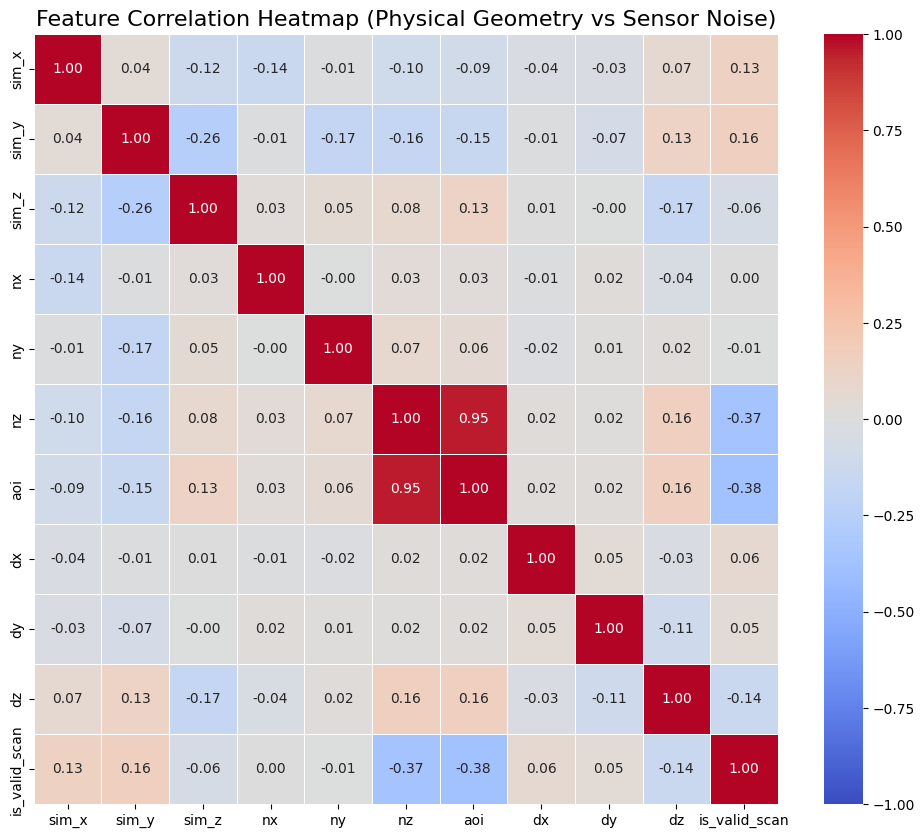

C:\Users\Alvan\AppData\Local\Temp\ipykernel_671564\2315223449.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aoi_dropout_rates = df_corr.groupby('aoi_bin')['is_valid_scan'].mean() * 100 # percentage that SURVIVED


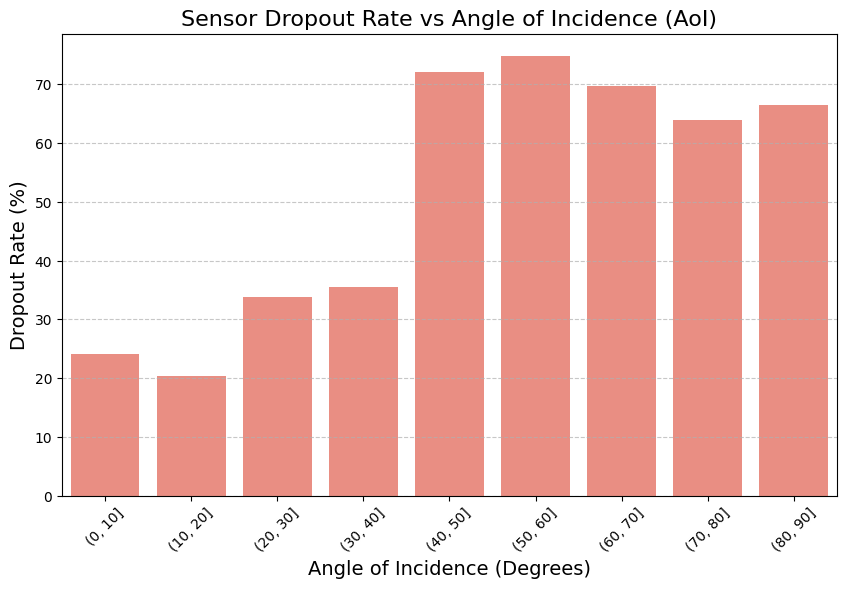

In [28]:
# ==========================================
# 14. CORRELATION ANALYSIS (AoI vs Dropout vs Noise)
# ==========================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

print("Loading expanded dataset for Correlation Analysis...")
csv_path = os.path.join(DATA_DIR, "extracted_noise_all_features.csv")
df_corr = pd.read_csv(csv_path)

# 1. Select the relevant features for the heatmap
features_to_correlate = ['sim_x', 'sim_y', 'sim_z', 'nx', 'ny', 'nz', 'aoi', 'dx', 'dy', 'dz', 'is_valid_scan']
df_heatmap = df_corr[features_to_correlate]

# 2. Calculate Pearson Correlation Matrix
corr_matrix = df_heatmap.corr(method='pearson')

# 3. Plot the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Physical Geometry vs Sensor Noise)", fontsize=16)
plt.show()

# 4. Plot AoI vs Dropout specifically (using a Bar Plot for clear visualization)
# Bin the AoI into 10-degree buckets to see how dropout increases with angle
df_corr['aoi_bin'] = pd.cut(df_corr['aoi'], bins=range(0, 100, 10))
aoi_dropout_rates = df_corr.groupby('aoi_bin')['is_valid_scan'].mean() * 100 # percentage that SURVIVED
aoi_dropout_rates = 100 - aoi_dropout_rates # Percentage that DROPPED OUT

plt.figure(figsize=(10, 6))
sns.barplot(x=aoi_dropout_rates.index.astype(str), y=aoi_dropout_rates.values, color='salmon')
plt.title("Sensor Dropout Rate vs Angle of Incidence (AoI)", fontsize=16)
plt.xlabel("Angle of Incidence (Degrees)", fontsize=14)
plt.ylabel("Dropout Rate (%)", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Analyzing Angle of Incidence for Viewpoint 5...


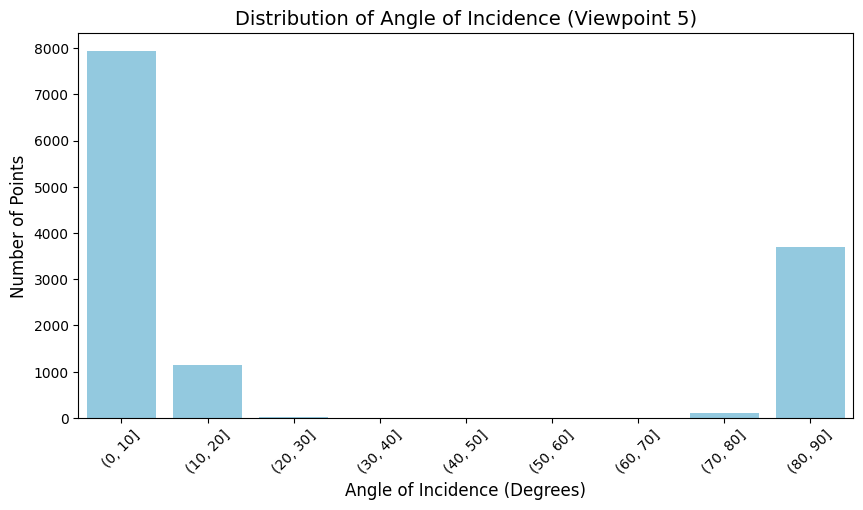


--- 3D Color Map Legend ---
Blue   = 0 degrees (Face-on to camera)
Green  = ~45 degrees
Red    = 90 degrees (Edge-on / Grazing angle)
Close the Open3D window to continue.


In [29]:
# ==========================================
# 15. VISUALIZE ANGLE OF INCIDENCE IN 3D
# ==========================================
import pandas as pd
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_VIEWPOINT = 5

print(f"Analyzing Angle of Incidence for Viewpoint {TARGET_VIEWPOINT}...")

csv_path = os.path.join(DATA_DIR, "extracted_noise_all_features.csv")
df_all = pd.read_csv(csv_path)
df_view = df_all[df_all['view_id'] == TARGET_VIEWPOINT].copy()

if len(df_view) == 0:
    print(f"No data found for viewpoint {TARGET_VIEWPOINT}")
else:
    # 1. Bar chart of AoI Distribution
    df_view['aoi_bin'] = pd.cut(df_view['aoi'], bins=range(0, 100, 10))
    aoi_counts = df_view['aoi_bin'].value_counts().sort_index()
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=aoi_counts.index.astype(str), y=aoi_counts.values, color='skyblue')
    plt.title(f"Distribution of Angle of Incidence (Viewpoint {TARGET_VIEWPOINT})", fontsize=14)
    plt.xlabel("Angle of Incidence (Degrees)", fontsize=12)
    plt.ylabel("Number of Points", fontsize=12)
    plt.xticks(rotation=45)
    plt.show()
    
    # 2. 3D Visualization colored by AoI
    points = df_view[['sim_x', 'sim_y', 'sim_z']].values
    aoi_values = df_view['aoi'].values
    
    # Normalize AoI from [0, 90] to [0, 1] for colormapping
    aoi_normalized = np.clip(aoi_values / 90.0, 0, 1)
    
    # Get colors from matplotlib colormap (Jet)
    cmap = plt.get_cmap("jet")
    colors = cmap(aoi_normalized)[:, :3] # get RGB, drop Alpha
    
    pcd_aoi = o3d.geometry.PointCloud()
    pcd_aoi.points = o3d.utility.Vector3dVector(points)
    pcd_aoi.colors = o3d.utility.Vector3dVector(colors)
    
    print("\n--- 3D Color Map Legend ---")
    print("Blue   = 0 degrees (Face-on to camera)")
    print("Green  = ~45 degrees")
    print("Red    = 90 degrees (Edge-on / Grazing angle)")
    print("Close the Open3D window to continue.")
    
    o3d.visualization.draw_geometries([pcd_aoi], window_name=f"AoI Colormap - View {TARGET_VIEWPOINT}")
